In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load FULL cleaned data (not sample)
df = pd.read_csv('../data/processed/cleaned_tweets.csv')

# Create balanced sample: 50000 negative + 50000 positive
negative_tweets = df[df['target'] == 0].sample(n=50000, random_state=42)
positive_tweets = df[df['target'] == 4].sample(n=50000, random_state=42)
df = pd.concat([negative_tweets, positive_tweets]).sample(frac=1, random_state=42)

print(f"Dataset Shape: {df.shape}")
print(f"\nTarget Distribution:")
print(df['target'].value_counts())
print(f"\nSample Data:")
df.head()


Dataset Shape: (100000, 2)

Target Distribution:
target
4    50000
0    50000
Name: count, dtype: int64

Sample Data:


,target,cleaned_text
1187977,4,rockefeller center eating banana bread pudding...
1492297,4,omfg wow ppl actually care overdose isnt awnse...
292534,0,lmao want dont many cap people twitter though ...
1380183,4,comeing back shopping breahead popping silverb...
1200736,4,tooo


In [2]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Check class distribution first
print("Target Distribution:")
print(df['target'].value_counts())

# Prepare data - convert 0→Negative, 4→Positive
X = df['cleaned_text']
y = df['target'].map({0: 0, 4: 1})

# Verify both classes exist
print(f"\nUnique classes: {y.unique()}")

# Split data with stratification (ensures both classes in train/test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Train class distribution:\n{y_train.value_counts()}")

Target Distribution:
target
4    50000
0    50000
Name: count, dtype: int64

Unique classes: [1 0]

Training samples: 80000
Testing samples: 20000
Train class distribution:
target
0    40000
1    40000
Name: count, dtype: int64


In [3]:
# 1. Bag of Words (BOW)
bow = CountVectorizer(max_features=5000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

# 2. TF-IDF (Recommended)
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("BOW shape:", X_train_bow.shape)
print("TF-IDF shape:", X_train_tfidf.shape)

BOW shape: (80000, 5000)
TF-IDF shape: (80000, 5000)


In [5]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Store results
results = []

# Model 1: Naive Bayes + TF-IDF (FAST)
print("Training Naive Bayes...")
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)
acc_nb = accuracy_score(y_test, y_pred_nb)
results.append(('Naive Bayes + TF-IDF', acc_nb))
print(f"✓ Naive Bayes Accuracy: {acc_nb:.4f}")

# Model 2: Logistic Regression + TF-IDF (FAST)
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, n_jobs=-1)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)
acc_lr = accuracy_score(y_test, y_pred_lr)
results.append(('Logistic Regression + TF-IDF', acc_lr))
print(f"✓ Logistic Regression Accuracy: {acc_lr:.4f}")

# Compare models
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy'])
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
print(results_df.sort_values('Accuracy', ascending=False))


Training Naive Bayes...
✓ Naive Bayes Accuracy: 0.7510
Training Logistic Regression...
✓ Logistic Regression Accuracy: 0.7652

MODEL COMPARISON
                          Model  Accuracy
1  Logistic Regression + TF-IDF   0.76525
0          Naive Bayes + TF-IDF   0.75095


DETAILED EVALUATION: Logistic Regression + TF-IDF

Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.78      0.75      0.76     10000
Positive (1)       0.76      0.78      0.77     10000

    accuracy                           0.77     20000
   macro avg       0.77      0.77      0.77     20000
weighted avg       0.77      0.77      0.77     20000

Confusion Matrix:
[[7471 2529]
 [2166 7834]]


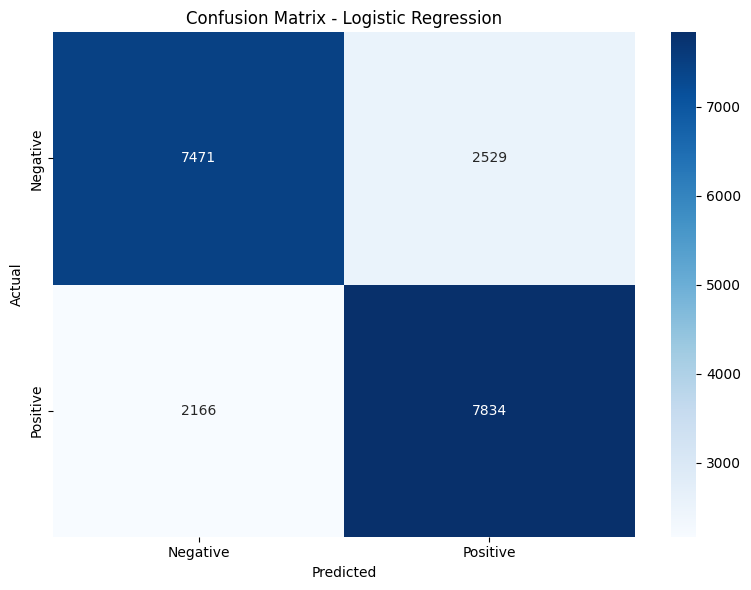

In [6]:
from sklearn.metrics import classification_report, confusion_matrix

# Use Logistic Regression (best model)
print("="*50)
print("DETAILED EVALUATION: Logistic Regression + TF-IDF")
print("="*50)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Negative (0)', 'Positive (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
print(f"Confusion Matrix:\n{cm}")

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

In [7]:
import joblib

# Save the trained model
joblib.dump(lr, '../models/sentiment_model.pkl')
print("✓ Model saved to: ../models/sentiment_model.pkl")

# Save the TF-IDF vectorizer
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')
print("✓ Vectorizer saved to: ../models/tfidf_vectorizer.pkl")

# Save class mapping
class_mapping = {0: 'Negative', 1: 'Positive'}
joblib.dump(class_mapping, '../models/class_mapping.pkl')
print("✓ Class mapping saved to: ../models/class_mapping.pkl")


✓ Model saved to: ../models/sentiment_model.pkl
✓ Vectorizer saved to: ../models/tfidf_vectorizer.pkl
✓ Class mapping saved to: ../models/class_mapping.pkl


In [8]:
# Test with sample tweets
test_tweets = [
    "i love this product its amazing",
    "this is terrible worst experience ever",
    "great service highly recommend",
    "im so disappointed wont buy again"
]

# Transform using saved vectorizer
test_vectors = tfidf.transform(test_tweets)

# Predict
predictions = lr.predict(test_vectors)
probabilities = lr.predict_proba(test_vectors)

# Display results
print("\n" + "="*50)
print("TEST PREDICTIONS")
print("="*50)

for i, tweet in enumerate(test_tweets):
    sentiment = "Positive" if predictions[i] == 1 else "Negative"
    confidence = probabilities[i][predictions[i]] * 100
    print(f"\nTweet: {tweet}")
    print(f"Sentiment: {sentiment} ({confidence:.1f}% confidence)")


TEST PREDICTIONS

Tweet: i love this product its amazing
Sentiment: Positive (97.2% confidence)

Tweet: this is terrible worst experience ever
Sentiment: Negative (88.0% confidence)

Tweet: great service highly recommend
Sentiment: Positive (81.6% confidence)

Tweet: im so disappointed wont buy again
Sentiment: Negative (97.5% confidence)
